# ✅ Paso 1: Instalación de librerías

In [1]:
# Instalar librerías
!pip install chembl_webresource_client
!pip install rdkit
!pip install tensorflow
!pip install scikit-learn
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 11.9 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


# ✅ Paso 2: Conexión a ChEMBL y descarga de datos

In [3]:
# https://difacquim.gitbook.io/quimioinformatica/4.-bases-de-datos-moleculares/4.2-chembl/4.2.1-api
# https://colab.research.google.com/drive/1pqp4t4LW9XLabyyuctJLkYlhz0Hcm2LV#scrollTo=dd0ENP_G3Jo8

In [4]:

from chembl_webresource_client.new_client import new_client
import pandas as pd

# Buscar targets relacionados con Alzheimer
target = new_client.target
targets = target.search("Alzheimer")
for t in targets:
    print(t['target_chembl_id'], t['pref_name'], t['organism'])

# Elegir un target con datos IC50 (ejemplo: Gamma-secretase)
activity = new_client.activity
res = activity.filter(target_chembl_id="CHEMBL2094135").filter(standard_type="IC50")
res = res.only(["molecule_chembl_id", "canonical_smiles", "standard_value", "standard_units"])
#lo que vamos a retener de la búsqueda es el chmbl id, código smile, y los valores y unidades estándar

#una vez tengo mi lista, para poder operar con mis datos tengo que generar un dataFrame, usando Pandas
# Convertir a DataFrame
data = list(res)
df = pd.DataFrame(data)
print("Datos descargados:", df.shape)
print(df.head())
#data es el listado de mi búsqueda, va a concatenar todos los resultados en una única variable, pero si imprimo data me lo imprime en formato clave valor, pero para poder trabajar mejor con IA es mejor utilizar dataFrames. Por esto transformo mi lista de datos en un dataFrame con Pandas



CHEMBL3085621 Nucleosome-remodeling factor subunit BPTF Homo sapiens
CHEMBL3418 Nicastrin Homo sapiens
CHEMBL2094135 Gamma-secretase Homo sapiens
CHEMBL3638365 Amyloid-beta precursor protein Rattus norvegicus
CHEMBL4523942 Amyloid-beta precursor protein Mus musculus
CHEMBL2487 Amyloid-beta precursor protein Homo sapiens
Datos descargados: (3542, 6)
                                    canonical_smiles molecule_chembl_id  \
0  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...       CHEMBL336071   
1  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...       CHEMBL336813   
2  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...       CHEMBL334594   
3  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...       CHEMBL133237   
4  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...       CHEMBL132900   

  standard_units standard_value units   value  
0             nM            1.8    nM     1.8  
1             nM            0.9    nM     0.9  
2             nM           13.2    nM    13.2  
3     

In [5]:
print(data)

[{'canonical_smiles': 'C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)OCO3)c2ccccc2NC1=O', 'molecule_chembl_id': 'CHEMBL336071', 'standard_units': 'nM', 'standard_value': '1.8', 'units': 'nM', 'value': '1.8'}, {'canonical_smiles': 'C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)OCO3)c2ccccc2N(CCO)C1=O', 'molecule_chembl_id': 'CHEMBL336813', 'standard_units': 'nM', 'standard_value': '0.9', 'units': 'nM', 'value': '0.9'}, {'canonical_smiles': 'C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)OCO3)c2ccccc2N(CC(N)=O)C1=O', 'molecule_chembl_id': 'CHEMBL334594', 'standard_units': 'nM', 'standard_value': '13.2', 'units': 'nM', 'value': '13.2'}, {'canonical_smiles': 'C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(=O)ccoc3c2)c2ccccc2N(C)C1=O', 'molecule_chembl_id': 'CHEMBL133237', 'standard_units': 'nM', 'standard_value': '1.2', 'units': 'nM', 'value': '1.2'}, {'canonical_smiles': 'C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3c(c2)CCN(C)C3=O)c2ccccc2N(C)C1=O', 'molecule_chembl_id': 

# ✅ Paso 3: Curación de datos


In [6]:

import numpy as np

# Eliminar valores nulos y duplicados
df = df.dropna().drop_duplicates()
#se eliminan valores no numéricos, ej>10nm el >10 no es un valor, pero si quisiera incluirlo haría rangos

# Convertir IC50 a numérico
df['IC50'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['IC50'])


# Transformación logarítmica
df['IC50_log'] = np.log10(df['IC50'])


# Mostrar datos limpios
print("Datos limpios:", df.shape)
print(df[['canonical_smiles', 'IC50', 'IC50_log']].head())


Datos limpios: (3174, 8)
                                    canonical_smiles    IC50  IC50_log
0  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...     1.8  0.255273
1  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...     0.9 -0.045757
2  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...    13.2  1.120574
3  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...     1.2  0.079181
4  C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...  1884.0  3.275081


# ✅ Paso 4: Generación de descriptores moleculares (Morgan Fingerprints)

In [7]:

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

# Crear generador Morgan moderno
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
#de PubChem se pueden sacar más cantidad de descriptores, pero el profe se ha centrado en los descriptores Morgan, lo que permite generar vectores con Radio 2 (tiene en cuenta la conectividad de los átomos 2 a 2 para generar los vectores)
#existen otros descriptores moleculares como potencial electrostático en superficie
#los descriptores morgan están en rdkit (librería para trabajar con moléculas pequeñas), este kit permite generar los descriptores vectoriales
#primero se define la función de morgan mediante el radio (cómo están conectados) y la resolución en píxeles

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = morgan_gen.GetFingerprint(mol)
        return np.array(fp)
    else:
        return np.zeros(1024)
#con esto genero una función para no tener que estar escribiendo lo mismo a mano. En esta función definimos el cambio de código smiles a descriptor molecular vectorial
#def es para crear una función, (smiles) es la variable que tu le vas a pedir al usuario, se le puede llamar como queramos
#primero defino una variable, rdkits no trabaja con Smiles, trabaja con mol, por lo que hay que pasar los códigos smile a formato mol. Chem es la librería de rdkit + MolFromSmiles y (smiles) será el que me meta el usuario
#entonces si el usuario no da un código smile correcto lo dice, pero si lo da, se genera el descriptor Morgan a partir de mol

# Crear matriz X e y
X = np.array([smiles_to_fingerprint(s) for s in df['canonical_smiles']])
y = df['IC50_log'].values
#esto es que, a la función que yo he definido, le voy a pasar todos los códigos smiles. (s) es el código smile

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (3174, 1024)
Forma de y: (3174,)


# ✅ Paso 5: Construcción del modelo con TensorFlow


In [8]:

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test sixe 0.1, están dividios en un 20% y van a estar randomizados

# Escalar datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#Para escalar estos datos estoy utilizando StandardScaler() PORQUE IMPORTANTE NO LO SE MIRARLO BIEN


# Definir modelo en TensorFlow (Red Neuronal simple)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # salida para regresión
])
#se que es un modelo neuronal por el Dense, que es un tipo de capa, si en lugar de layer ponemos RandomForest hacemos una IA de toma de decisiones
#tf.keras es un subprograma de tf que ayuda a generar modelos. Secuencial significa modelo que construimos capa sobre capa. Le vamos a dar un input que tiene que pasar por cada una de las capas
#la profundidad de la red neuronal se 4, hay 4 capas. Los tipos de capas son Densas lo que significa que las neuronas están hiperconectadas, la neurona de una capa está conectada a todas las neuronas de la capa anterior y de la posterior, pero no se conecta con las neuronas de la misma capa
#256 el nº de neuronas que tiene la capa 1, relu es regresión lineal (hace que no sea una combinación lineal de los datos, qeu se le pueda aplicar diferentes pesos a cada uno de los descriptores moleculares), y le vamos a decir que para esta priemra capa le vamos a meter el imput (la información va a entrar por la priemra capa)
#el resto de capas siguen la misma estructura, normalmente las redes neuronales se construyen de más número de neuronas a menos, para que saque un único datos, va en forma cónica hacia la generación de un único dato



model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#nuestro verificador de parámetros es adam, basándose en la métrica mse y mae. Lo que dice es que trate el optimizador para hacer que el dato real se parezca mucho al dato predicho. 1o le digo a la día con este descriptor tengo esta IC50, y el compilador le dice a la IA ¿con estos mismos descriptores moleculares que IC50 debería tener? Esto permite reducir el error entre el modelo de entrenamiento y el resultado


# Entrenar modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)
#vamos a entrenar la Ia con History, 50 son 50 ciclos, batch_size es que tengo 3150 moléculas de las cuales el 8% van para training, y voy a usar bloques de 32 para entrenar, se usan 32 y si no funciona bien se usan otros 32. La validación está en 0.2


# Evaluar modelo
loss, mae = model.evaluate(X_test, y_test)
print(f"MAE en test: {mae:.2f}")


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.9316 - mae: 1.0796 - val_loss: 0.9680 - val_mae: 0.7647
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5242 - mae: 0.5474 - val_loss: 0.9504 - val_mae: 0.7366
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3867 - mae: 0.4420 - val_loss: 0.8930 - val_mae: 0.7112
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3188 - mae: 0.3965 - val_loss: 0.9951 - val_mae: 0.7572
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3483 - mae: 0.4002 - val_loss: 0.9619 - val_mae: 0.7373
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3007 - mae: 0.3764 - val_loss: 0.9532 - val_mae: 0.7359
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2837 - mae: 0.3781 - val_loss: 0.9789 - val_mae: 0.7506
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2846 - mae: 0.3654 - val_loss: 0.9897 - val_mae: 0.7429
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2730 - mae: 0.3518 - 

# ✅ Paso 6: Métricas y Gráficas

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Métricas del modelo:
MSE: 1.02
RMSE: 1.01
R²: 0.4810


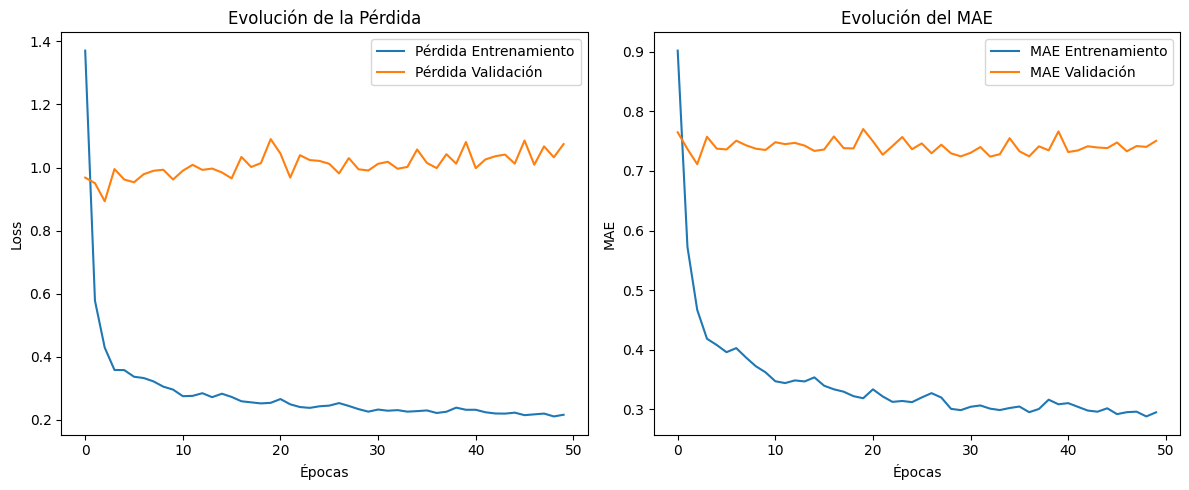

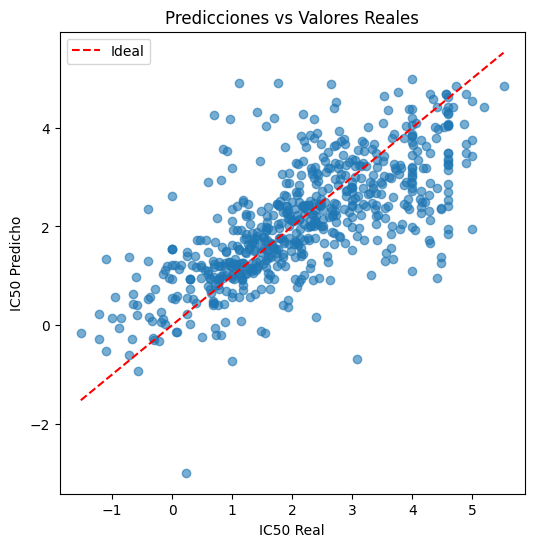

In [9]:

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
#ahora vamos a evaluar los parámetros de la IA, para ver lo bueno o lo malo que es

# Predicciones en test
y_pred = model.predict(X_test).flatten()
#este test genera una serie de métricas, ahora voy a probar a la IA con el 20% de los datos, el 80% se usó para entrenar
#aquí le digo predice todo lo uqe haya en x_test y llámalo y_pred. flatten es que lo ejecute.
#ahora tengo que comparar los valores predichos con los reales y hacer una estimación de cómo se parecen

# Calcular métricas adicionales
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
#una de las medias que se mide es el mse (R2)


print("\nMétricas del modelo:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

# === Gráficas del entrenamiento ===
plt.figure(figsize=(12,5))

# Gráfico de pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfico de MAE
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='MAE Entrenamiento')
plt.plot(history.history['val_mae'], label='MAE Validación')
plt.title('Evolución del MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# === Visualización de predicciones vs valores reales ===
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Ideal')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('IC50 Real')
plt.ylabel('IC50 Predicho')
plt.legend()
plt.show()

#los resultados son así de malos porque hemos escalado los datos X pero no los y (datos iniciales, no los que vemos). Cuando lo ajustamos a un logaritmo la regresión se adecúa más a los valores y la gráfica se estabiliza

# ✅ Paso 7: Predicción para nuevos compuestos

In [10]:

# Nuevos compuestos en formato SMILES
nuevos_smiles = [
    "CC(=O)Oc1ccccc1C(=O)O",  # ácido acetilsalicílico
    "C1=CC=C(C=C1)O"          # fenol
]

# Convertir a fingerprints y escalar
X_nuevos = np.array([smiles_to_fingerprint(s) for s in nuevos_smiles])
X_nuevos = scaler.transform(X_nuevos)

# Predecir IC50
predicciones = model.predict(X_nuevos)

# Mostrar resultados
for smi, ic50 in zip(nuevos_smiles, predicciones.flatten()):
    print(f"SMILES: {smi} → IC50 predicho: {ic50:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
SMILES: CC(=O)Oc1ccccc1C(=O)O → IC50 predicho: 4.36
SMILES: C1=CC=C(C=C1)O → IC50 predicho: 3.94


# ✅ Paso 8: Guardar el modelo

In [11]:

from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/modelo_ic50_avanzado.h5')
loaded = keras.models.load_model('/content/drive/MyDrive/modelo_ic50_avanzado.h5')

ValueError: mount failed

# EXTRA

In [ ]:

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors
import numpy as np
import pandas as pd

# Generador de fingerprints Morgan
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Función para calcular fingerprints + descriptores
def smiles_to_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Fingerprint Morgan
        fp = np.array(morgan_gen.GetFingerprint(mol))
        # Descriptores físico-químicos
        desc = [
            Descriptors.MolWt(mol),          # Peso molecular
            Descriptors.MolLogP(mol),        # LogP (hidrofobicidad)
            Descriptors.NumHDonors(mol),     # Donadores de H
            Descriptors.NumHAcceptors(mol)   # Aceptores de H
        ]
        return np.concatenate([fp, desc])
    else:
        return np.zeros(2048 + 4)

# Aplicar a todo el DataFrame con SMILES
X = np.array([smiles_to_features(s) for s in df['canonical_smiles']])
y = df['IC50_log'].values  # Usamos IC50 en escala logarítmica

print("Forma de X (fingerprints + descriptores):", X.shape)
print("Forma de y:", y.shape)


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stop, lr_scheduler, checkpoint])


In [ ]:

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Curvas de entrenamiento
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Loss Train')
plt.plot(history.history['val_loss'], label='Loss Val')
plt.title('Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='MAE Train')
plt.plot(history.history['val_mae'], label='MAE Val')
plt.title('MAE')
plt.legend()
plt.show()

# Predicciones vs reales
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Ideal')
plt.title('Predicciones vs Valores Reales (log10 IC50)')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.legend()
plt.show()

# Residuos
plt.figure(figsize=(6,4))
plt.hist(y_test - y_pred, bins=30, alpha=0.7)
plt.title('Distribución de errores')
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.show()


In [ ]:

nuevos_smiles = ["CC(=O)Oc1ccccc1C(=O)O", "C1=CC=C(C=C1)O"]
X_nuevos = np.array([smiles_to_features(s) for s in nuevos_smiles])
X_nuevos = scaler.transform(X_nuevos)

pred_log = model.predict(X_nuevos).flatten()
pred_ic50 = 10**pred_log

for smi, ic50 in zip(nuevos_smiles, pred_ic50):
    print(f"SMILES: {smi} → IC50 predicho: {ic50:.2f}")


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/modelo_ic50_avanzado.h5')
